Epoch 0: D Loss: 1.3821, G Loss: 0.7446
Epoch 100: D Loss: 1.1944, G Loss: 0.8948
Epoch 200: D Loss: 0.9728, G Loss: 1.0060
Epoch 300: D Loss: 1.5889, G Loss: 0.7008
Epoch 400: D Loss: 1.1603, G Loss: 1.1272
Epoch 500: D Loss: 1.3157, G Loss: 0.8380
Epoch 600: D Loss: 1.6122, G Loss: 0.4549
Epoch 700: D Loss: 1.3454, G Loss: 1.0529
Epoch 800: D Loss: 0.9094, G Loss: 1.0594
Epoch 900: D Loss: 1.5425, G Loss: 0.7603
Epoch 1000: D Loss: 0.9064, G Loss: 1.0559
Epoch 1100: D Loss: 0.7316, G Loss: 1.4166
Epoch 1200: D Loss: 1.3119, G Loss: 0.7557
Epoch 1300: D Loss: 1.0328, G Loss: 1.3245
Epoch 1400: D Loss: 1.2014, G Loss: 0.9161
Epoch 1500: D Loss: 1.1841, G Loss: 0.9604
Epoch 1600: D Loss: 1.2884, G Loss: 0.6915
Epoch 1700: D Loss: 0.7026, G Loss: 1.3690
Epoch 1800: D Loss: 0.9314, G Loss: 1.2484
Epoch 1900: D Loss: 0.7495, G Loss: 1.2689
Epoch 2000: D Loss: 0.8285, G Loss: 1.3510
Epoch 2100: D Loss: 0.5847, G Loss: 1.6709
Epoch 2200: D Loss: 1.5088, G Loss: 0.4310
Epoch 2300: D Loss: 0.9

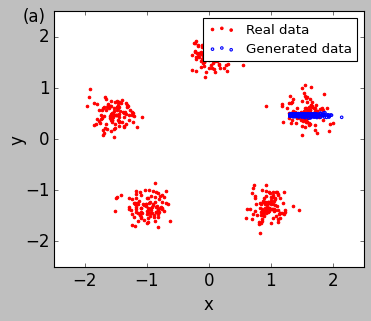

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
from sklearn.mixture import GaussianMixture
import copy

# 设置随机数种子
seed = 74###########连续5次随机种子看看是否成功
torch.manual_seed(seed) #设置Pytorch的随机种子
np.random.seed(seed) #设置Numpy的随机种子

def genGauss(p, n=1, r=1): #生成高斯分布的随机数据，并进行一定的预处理，返回一个归一化的训练数据集，便于进一步分析或建模。
    x = []
    y = []
    for k in range(n):#使用for循环从0到n-1进行迭代，每次迭代生成一组高斯分布的点
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)
    #np.random.multivariate_normal 函数用来生成多元正态分布的数据。
    #第一参数是均值 [math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)]，表示每组数据的中心点
    #第二参数是协方差矩阵 [[0.0125, 0], [0, 0.0125]]，表示数据的分散程度。
    #第三参数 p 是需要生成的样本数量。.T 是对生成的数据进行转置，便于后续处理。
    
    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()

    def forward(self, z_input): #定义前向传播方法，该方法在输入数据通过模型时被调用
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()#定义 ReLU 激活函数的实例 relu，在每个全连接层后将会使用。
        self.sigmoid = nn.Sigmoid()#定义 Sigmoid 激活函数的实例 sigmoid，用于输出层。

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

def generator_loss(d_fake):
    # 生成器希望 d_fake 接近 1
    return -torch.mean(torch.log(d_fake + 1e-8))

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 5000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

# Training loop
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train generator
        d_fake, _ = discriminator(fake_img)

        # 使用自定义的生成器损失函数
        g_loss = generator_loss(d_fake)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))

    # Print losses every 20 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, G Loss: {np.mean(batch_generator_loss):.4f}")
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['classic'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig2a.eps', dpi=800)
# 显示图 (a)
plt.show()

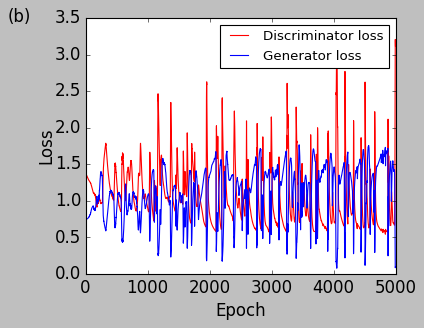

In [2]:
# 图 (b): 损失曲线
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('Epoch', fontsize=15)
ax.set_ylabel('Loss', fontsize=15, labelpad=-1)

# 绘制判别器损失曲线
ax.plot(epoch_discriminator_loss, color='red', label='Discriminator loss')
# 绘制生成器损失曲线
ax.plot(epoch_generator_loss, color='blue', label='Generator loss')
ax.legend(loc='upper right', fontsize=12)
ax.text(-1250, max(epoch_discriminator_loss) + 0.1, '(b)', fontsize=15)  # 标记 (b)
#fig.savefig('D:/GAN2024/Fig2b.eps', dpi=800)
# 显示图 (b)
plt.show()

In [3]:
# 估计GMM参数
gmm_real = GaussianMixture(n_components=2, covariance_type='full', random_state=seed).fit(X_train)
gmm_gen = GaussianMixture(n_components=2, covariance_type='full', random_state=seed).fit(samples)
        
# 计算评分（可以使用AIC, BIC等）值越低越好
score_real = gmm_real.aic(X_train)
score_gen = gmm_gen.aic(samples)
print(score_gen)

-7590.6536027215425


Epoch 0: D Loss: 1.4052, G Loss: 0.5775
Epoch 100: D Loss: 1.1398, G Loss: 0.7679
Epoch 200: D Loss: 0.9261, G Loss: 0.9477
Epoch 300: D Loss: 1.2485, G Loss: 0.9889
Epoch 400: D Loss: 1.4832, G Loss: 1.0177
Epoch 500: D Loss: 1.2025, G Loss: 0.8397
Epoch 600: D Loss: 1.2207, G Loss: 0.8507
Epoch 700: D Loss: 1.2620, G Loss: 0.9217
Epoch 800: D Loss: 1.2813, G Loss: 0.7719
Epoch 900: D Loss: 1.1100, G Loss: 1.0199
Epoch 1000: D Loss: 1.2688, G Loss: 0.7954
Epoch 1100: D Loss: 1.2234, G Loss: 0.8273
Epoch 1200: D Loss: 1.2914, G Loss: 0.8431
Epoch 1300: D Loss: 1.5276, G Loss: 0.4948
Epoch 1400: D Loss: 1.1683, G Loss: 0.9424
Epoch 1500: D Loss: 1.3736, G Loss: 0.6485
Epoch 1600: D Loss: 1.1957, G Loss: 0.9006
Epoch 1700: D Loss: 1.1144, G Loss: 0.9886
Epoch 1800: D Loss: 0.9414, G Loss: 1.1016
Epoch 1900: D Loss: 0.9419, G Loss: 1.1087
Epoch 2000: D Loss: 1.0925, G Loss: 1.0071
Epoch 2100: D Loss: 0.9511, G Loss: 1.0670
Epoch 2200: D Loss: 1.0317, G Loss: 1.0313
Epoch 2300: D Loss: 0.9

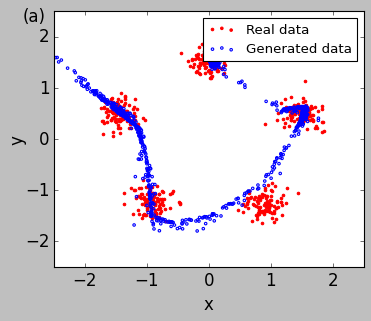

In [4]:
##第二次实验
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
from sklearn.mixture import GaussianMixture
import copy


# 设置随机数种子
seed = 42###########连续5次随机种子看看是否成功
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

def generator_loss(d_fake):
    # 生成器希望 d_fake 接近 1
    return -torch.mean(torch.log(d_fake + 1e-8))

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 5000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

# Training loop
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train generator
        d_fake, _ = discriminator(fake_img)

        # 使用自定义的生成器损失函数
        g_loss = generator_loss(d_fake)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))

    # Print losses every 20 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, G Loss: {np.mean(batch_generator_loss):.4f}")
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['classic'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig2a.eps', dpi=800)
# 显示图 (a)
plt.show()

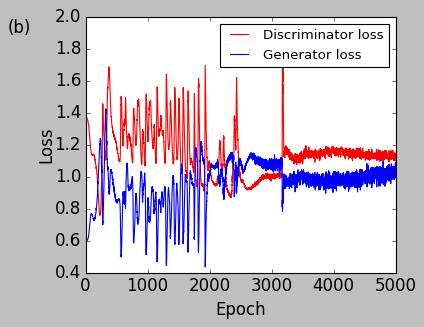

In [5]:
# 图 (b): 损失曲线
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('Epoch', fontsize=15)
ax.set_ylabel('Loss', fontsize=15, labelpad=-1)

# 绘制判别器损失曲线
ax.plot(epoch_discriminator_loss, color='red', label='Discriminator loss')
# 绘制生成器损失曲线
ax.plot(epoch_generator_loss, color='blue', label='Generator loss')
ax.legend(loc='upper right', fontsize=12)
ax.text(-1250, max(epoch_discriminator_loss) + 0.1, '(b)', fontsize=15)  # 标记 (b)
#fig.savefig('D:/GAN2024/Fig2b.eps', dpi=800)
# 显示图 (b)
plt.show()

In [6]:
# 估计GMM参数
gmm_real = GaussianMixture(n_components=2, covariance_type='full', random_state=seed).fit(X_train)
gmm_gen = GaussianMixture(n_components=2, covariance_type='full', random_state=seed).fit(samples)
        
# 计算评分（可以使用AIC, BIC等）值越低越好
score_real = gmm_real.aic(X_train)
score_gen = gmm_gen.aic(samples)
print(score_gen)

3525.914986602549


Epoch 0: D Loss: 1.4032, G Loss: 0.8447
Epoch 100: D Loss: 1.0748, G Loss: 0.9954
Epoch 200: D Loss: 1.2298, G Loss: 0.8358
Epoch 300: D Loss: 1.3034, G Loss: 0.6511
Epoch 400: D Loss: 1.0110, G Loss: 1.2022
Epoch 500: D Loss: 0.9326, G Loss: 1.2477
Epoch 600: D Loss: 2.1477, G Loss: 0.4718
Epoch 700: D Loss: 0.9870, G Loss: 1.0244
Epoch 800: D Loss: 1.4808, G Loss: 0.5710
Epoch 900: D Loss: 1.2298, G Loss: 1.2207
Epoch 1000: D Loss: 0.8038, G Loss: 1.0842
Epoch 1100: D Loss: 1.7369, G Loss: 0.5339
Epoch 1200: D Loss: 1.1627, G Loss: 0.7763
Epoch 1300: D Loss: 1.4028, G Loss: 0.8783
Epoch 1400: D Loss: 0.8978, G Loss: 1.1233
Epoch 1500: D Loss: 0.8570, G Loss: 1.1710
Epoch 1600: D Loss: 1.4240, G Loss: 1.0122
Epoch 1700: D Loss: 0.8461, G Loss: 1.2897
Epoch 1800: D Loss: 0.6610, G Loss: 1.4766
Epoch 1900: D Loss: 1.9775, G Loss: 0.7368
Epoch 2000: D Loss: 0.8602, G Loss: 1.2334
Epoch 2100: D Loss: 0.8860, G Loss: 0.9857
Epoch 2200: D Loss: 0.8990, G Loss: 1.0488
Epoch 2300: D Loss: 0.7

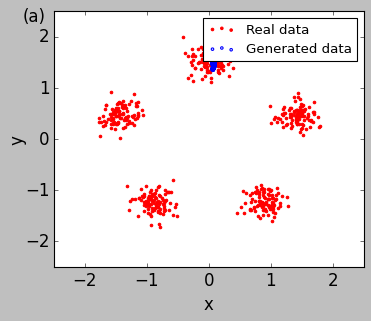

In [7]:
##第3次实验
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
from sklearn.mixture import GaussianMixture
import copy


# 设置随机数种子
seed = 166###########连续5次随机种子看看是否成功
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

def generator_loss(d_fake):
    # 生成器希望 d_fake 接近 1
    return -torch.mean(torch.log(d_fake + 1e-8))

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 5000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

# Training loop
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train generator
        d_fake, _ = discriminator(fake_img)

        # 使用自定义的生成器损失函数
        g_loss = generator_loss(d_fake)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))

    # Print losses every 20 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, G Loss: {np.mean(batch_generator_loss):.4f}")
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['classic'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig2a.eps', dpi=800)
# 显示图 (a)
plt.show()

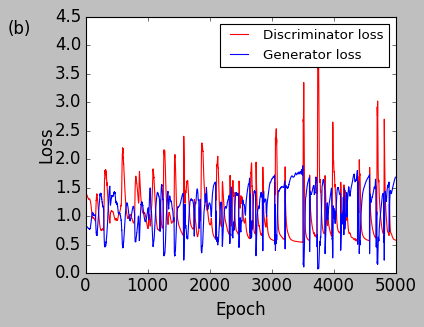

In [8]:
# 图 (b): 损失曲线
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('Epoch', fontsize=15)
ax.set_ylabel('Loss', fontsize=15, labelpad=-1)

# 绘制判别器损失曲线
ax.plot(epoch_discriminator_loss, color='red', label='Discriminator loss')
# 绘制生成器损失曲线
ax.plot(epoch_generator_loss, color='blue', label='Generator loss')
ax.legend(loc='upper right', fontsize=12)
ax.text(-1250, max(epoch_discriminator_loss) + 0.1, '(b)', fontsize=15)  # 标记 (b)
#fig.savefig('D:/GAN2024/Fig2b.eps', dpi=800)
# 显示图 (b)
plt.show()

In [9]:
# 估计GMM参数
gmm_real = GaussianMixture(n_components=2, covariance_type='full', random_state=seed).fit(X_train)
gmm_gen = GaussianMixture(n_components=2, covariance_type='full', random_state=seed).fit(samples)
        
# 计算评分（可以使用AIC, BIC等）值越低越好
score_real = gmm_real.aic(X_train)
score_gen = gmm_gen.aic(samples)
print(score_gen)

-7932.58077183077


Epoch 0: D Loss: 1.4178, G Loss: 0.8871
Epoch 100: D Loss: 1.2780, G Loss: 0.8675
Epoch 200: D Loss: 1.0630, G Loss: 1.0511
Epoch 300: D Loss: 1.3211, G Loss: 0.8966
Epoch 400: D Loss: 1.1745, G Loss: 0.8920
Epoch 500: D Loss: 1.5625, G Loss: 0.6575
Epoch 600: D Loss: 1.2445, G Loss: 0.6845
Epoch 700: D Loss: 1.3271, G Loss: 1.0255
Epoch 800: D Loss: 1.1595, G Loss: 0.7254
Epoch 900: D Loss: 0.8847, G Loss: 1.3764
Epoch 1000: D Loss: 1.6691, G Loss: 0.8985
Epoch 1100: D Loss: 1.1954, G Loss: 0.9067
Epoch 1200: D Loss: 1.1283, G Loss: 0.8834
Epoch 1300: D Loss: 0.6950, G Loss: 1.3393
Epoch 1400: D Loss: 1.2782, G Loss: 0.9311
Epoch 1500: D Loss: 1.1701, G Loss: 1.1239
Epoch 1600: D Loss: 1.0111, G Loss: 1.0219
Epoch 1700: D Loss: 1.1611, G Loss: 0.9642
Epoch 1800: D Loss: 0.9789, G Loss: 1.2593
Epoch 1900: D Loss: 0.9651, G Loss: 1.1146
Epoch 2000: D Loss: 1.1440, G Loss: 0.9830
Epoch 2100: D Loss: 1.0472, G Loss: 1.0731
Epoch 2200: D Loss: 0.9745, G Loss: 1.1226
Epoch 2300: D Loss: 0.9

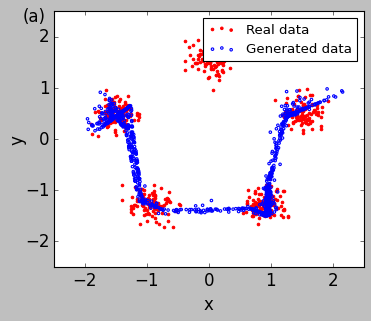

In [10]:
##第4次实验
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
from sklearn.mixture import GaussianMixture
import copy


# 设置随机数种子
seed = 1234###########连续5次随机种子看看是否成功
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

def generator_loss(d_fake):
    # 生成器希望 d_fake 接近 1
    return -torch.mean(torch.log(d_fake + 1e-8))

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 5000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

# Training loop
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train generator
        d_fake, _ = discriminator(fake_img)

        # 使用自定义的生成器损失函数
        g_loss = generator_loss(d_fake)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))

    # Print losses every 20 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, G Loss: {np.mean(batch_generator_loss):.4f}")
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['classic'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig2a.eps', dpi=800)
# 显示图 (a)
plt.show()

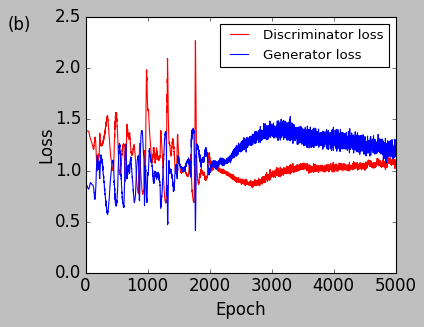

In [11]:
# 图 (b): 损失曲线
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('Epoch', fontsize=15)
ax.set_ylabel('Loss', fontsize=15, labelpad=-1)

# 绘制判别器损失曲线
ax.plot(epoch_discriminator_loss, color='red', label='Discriminator loss')
# 绘制生成器损失曲线
ax.plot(epoch_generator_loss, color='blue', label='Generator loss')
ax.legend(loc='upper right', fontsize=12)
ax.text(-1250, max(epoch_discriminator_loss) + 0.1, '(b)', fontsize=15)  # 标记 (b)
#fig.savefig('D:/GAN2024/Fig2b.eps', dpi=800)
# 显示图 (b)
plt.show()

In [12]:
# 估计GMM参数
gmm_real = GaussianMixture(n_components=2, covariance_type='full', random_state=seed).fit(X_train)
gmm_gen = GaussianMixture(n_components=2, covariance_type='full', random_state=seed).fit(samples)
        
# 计算评分（可以使用AIC, BIC等）值越低越好
score_real = gmm_real.aic(X_train)
score_gen = gmm_gen.aic(samples)
print(score_gen)

3204.980359671461


Epoch 0: D Loss: 1.3671, G Loss: 0.6592
Epoch 100: D Loss: 1.0898, G Loss: 0.7874
Epoch 200: D Loss: 0.7634, G Loss: 1.0441
Epoch 300: D Loss: 0.9864, G Loss: 1.2963
Epoch 400: D Loss: 1.0941, G Loss: 1.4287
Epoch 500: D Loss: 1.1087, G Loss: 0.7104
Epoch 600: D Loss: 1.1222, G Loss: 1.3846
Epoch 700: D Loss: 0.8610, G Loss: 1.1333
Epoch 800: D Loss: 1.1643, G Loss: 1.0738
Epoch 900: D Loss: 1.0356, G Loss: 1.0759
Epoch 1000: D Loss: 0.9915, G Loss: 1.1089
Epoch 1100: D Loss: 0.8584, G Loss: 1.2598
Epoch 1200: D Loss: 0.8386, G Loss: 1.2093
Epoch 1300: D Loss: 1.0680, G Loss: 1.1069
Epoch 1400: D Loss: 0.9806, G Loss: 1.1016
Epoch 1500: D Loss: 0.9092, G Loss: 1.1864
Epoch 1600: D Loss: 0.9218, G Loss: 1.2002
Epoch 1700: D Loss: 0.9495, G Loss: 1.2685
Epoch 1800: D Loss: 0.9707, G Loss: 1.2942
Epoch 1900: D Loss: 0.9717, G Loss: 1.3167
Epoch 2000: D Loss: 0.9441, G Loss: 1.3725
Epoch 2100: D Loss: 0.9265, G Loss: 1.4158
Epoch 2200: D Loss: 0.9745, G Loss: 1.3249
Epoch 2300: D Loss: 0.9

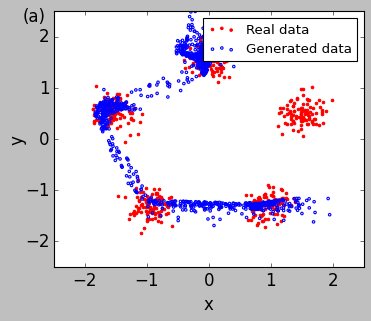

In [13]:
##第5次实验
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
from sklearn.mixture import GaussianMixture
import copy


# 设置随机数种子
seed = 4321###########连续5次随机种子看看是否成功
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

def generator_loss(d_fake):
    # 生成器希望 d_fake 接近 1
    return -torch.mean(torch.log(d_fake + 1e-8))

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 5000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

# Training loop
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train generator
        d_fake, _ = discriminator(fake_img)

        # 使用自定义的生成器损失函数
        g_loss = generator_loss(d_fake)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))

    # Print losses every 20 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, G Loss: {np.mean(batch_generator_loss):.4f}")
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['classic'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig2a.eps', dpi=800)
# 显示图 (a)
plt.show()

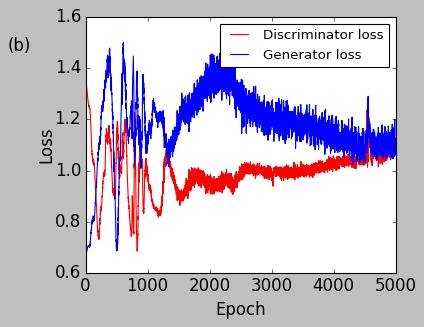

In [14]:
# 图 (b): 损失曲线
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('Epoch', fontsize=15)
ax.set_ylabel('Loss', fontsize=15, labelpad=-1)

# 绘制判别器损失曲线
ax.plot(epoch_discriminator_loss, color='red', label='Discriminator loss')
# 绘制生成器损失曲线
ax.plot(epoch_generator_loss, color='blue', label='Generator loss')
ax.legend(loc='upper right', fontsize=12)
ax.text(-1250, max(epoch_discriminator_loss) + 0.1, '(b)', fontsize=15)  # 标记 (b)
#fig.savefig('D:/GAN2024/Fig2b.eps', dpi=800)
# 显示图 (b)
plt.show()

In [15]:
# 估计GMM参数
gmm_real = GaussianMixture(n_components=2, covariance_type='full', random_state=seed).fit(X_train)
gmm_gen = GaussianMixture(n_components=2, covariance_type='full', random_state=seed).fit(samples)
        
# 计算评分（可以使用AIC, BIC等）值越低越好
score_real = gmm_real.aic(X_train)
score_gen = gmm_gen.aic(samples)
print(score_gen)

3265.780327359883


In [ ]:
################针对上述种子利用梯度噪声的实验

Epoch 0: D Loss: 1.3794, G Loss: 0.7441
Epoch 20: D Loss: 1.3691, G Loss: 0.7404
Epoch 40: D Loss: 1.3520, G Loss: 0.7392
Epoch 60: D Loss: 1.3338, G Loss: 0.7387
Epoch 80: D Loss: 1.3087, G Loss: 0.7440
Epoch 100: D Loss: 1.2818, G Loss: 0.7545
Epoch 120: D Loss: 1.2426, G Loss: 0.7714
Epoch 140: D Loss: 1.1968, G Loss: 0.8010
Epoch 160: D Loss: 1.1385, G Loss: 0.8330
Epoch 180: D Loss: 1.0757, G Loss: 0.8801
Epoch 200: D Loss: 1.0109, G Loss: 0.9362
Epoch 220: D Loss: 0.9651, G Loss: 0.9790
Epoch 240: D Loss: 0.9555, G Loss: 1.0034
Epoch 260: D Loss: 1.0042, G Loss: 1.0194
Epoch 280: D Loss: 1.0670, G Loss: 1.0843
Epoch 300: D Loss: 1.0433, G Loss: 1.2183
Epoch 320: D Loss: 0.9979, G Loss: 1.3100
Epoch 340: D Loss: 0.9586, G Loss: 1.3269
Epoch 360: D Loss: 0.9338, G Loss: 1.3025
Epoch 380: D Loss: 0.9109, G Loss: 1.2703
Epoch 400: D Loss: 0.8847, G Loss: 1.2332
Epoch 420: D Loss: 0.8888, G Loss: 1.1951
Epoch 440: D Loss: 0.8546, G Loss: 1.1818
Epoch 460: D Loss: 0.8893, G Loss: 1.104

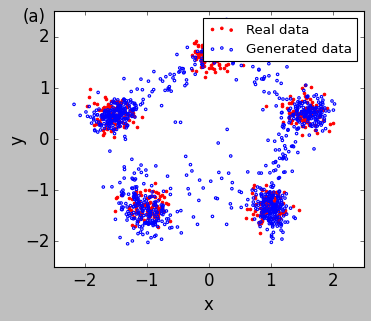

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
from sklearn.mixture import GaussianMixture
import copy


# 设置随机数种子
seed = 74
torch.manual_seed(seed)
np.random.seed(seed)


#定义生成高斯混合分布的函数
def genGauss(p, n=1, r=1): #高斯函数的三个参数：P用于生成多元正态分布的样本总数；n生成样本的维数; r用于缩放输出数据的因子
    x = []
    y = [] #两个空列表用于存放生成样本的x和y坐标
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)
    #生成P个二维正态分布的样本。第一个参数是分布的均值;第二个参数是分布的协方差矩阵
    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y) #对x和y进行中心化操作，即减去各自的均值
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)


#生成器
class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std=0):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()
        self.noise_std = noise_std

    def forward(self, z_input):
        # 添加噪声到输入
        z_input = z_input + torch.randn_like(z_input) * self.noise_std
        g_y1 = self.relu(self.fc1(z_input))
        g_y1 = g_y1 + torch.randn_like(g_y1) * self.noise_std  # 添加噪声到隐藏层
        g_y2 = self.relu(self.fc2(g_y1))
        g_y2 = g_y2 + torch.randn_like(g_y2) * self.noise_std  # 添加噪声到隐藏层
        g_y3 = self.relu(self.fc3(g_y2))
        g_y3 = g_y3 + torch.randn_like(g_y3) * self.noise_std  # 添加噪声到隐藏层
        g_y4 = self.fc4(g_y3)
        return g_y4


#判别器
class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std=0):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.noise_std = noise_std

    def forward(self, x_input):
        # 添加噪声到输入
        x_input = x_input + torch.randn_like(x_input) * self.noise_std
        d_y1 = self.relu(self.fc1(x_input))
        d_y1 = d_y1 + torch.randn_like(d_y1) * self.noise_std  # 添加噪声到隐藏层
        d_y2 = self.relu(self.fc2(d_y1))
        d_y2 = d_y2 + torch.randn_like(d_y2) * self.noise_std  # 添加噪声到隐藏层
        d_y3 = self.relu(self.fc3(d_y2))
        d_y3 = d_y3 + torch.randn_like(d_y3) * self.noise_std  # 添加噪声到隐藏层
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4)
        return output, d_y4


# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

def generator_loss(d_fake):
    # 生成器希望 d_fake 接近 1
    return -torch.mean(torch.log(d_fake + 1e-8))


# 梯度噪声注入函数
def add_gradient_noise(parameters, grad_noise_std):
    for param in parameters:
        if param.grad is not None:
            noise = torch.randn_like(param.grad) * grad_noise_std
            param.grad += noise


# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32
noise_std = 0.05  # 隐藏层噪声标准差
grad_noise_std = 0.02  # 梯度噪声标准差

z_dim = 2
x_dim = 2
img_dim = 2


# Initialize models 初始化模型
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std)


# Optimizers 优化器
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)


#真实数据
epochs = 5000
X_train = genGauss(100, 5, 0.5) #生成一个高斯分布的数据集，其中包含 100 个样本，每个样本有 5 个特征，标准差为 0.5。
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []


# Training loop
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        add_gradient_noise(discriminator.parameters(), grad_noise_std)  # 梯度噪声注入
        d_optimizer.step()

        # Train generator
        d_fake, _ = discriminator(fake_img)

        # 使用自定义的生成器损失函数
        g_loss = generator_loss(d_fake)

        g_optimizer.zero_grad()
        g_loss.backward()
        add_gradient_noise(generator.parameters(), grad_noise_std)  # 梯度噪声注入
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))

    # Print losses every 20 epochs
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, G Loss: {np.mean(batch_generator_loss):.4f}")


plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['classic'])
#生成数据
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
# fig.savefig('D:/GAN2024/Fig1a.eps', dpi=800)
# 显示图 (a)
plt.show()

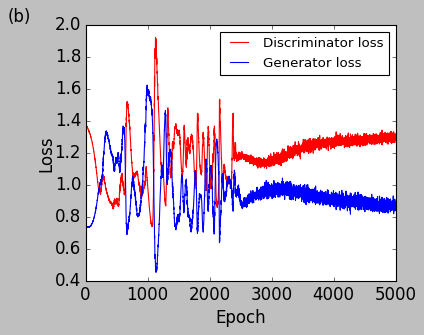

In [17]:
# 图 (b): 损失曲线
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('Epoch', fontsize=15)
ax.set_ylabel('Loss', fontsize=15, labelpad=-1)

# 绘制判别器损失曲线
ax.plot(epoch_discriminator_loss, color='red', label='Discriminator loss')
# 绘制生成器损失曲线
ax.plot(epoch_generator_loss, color='blue', label='Generator loss')
ax.legend(loc='upper right', fontsize=12)
ax.text(-1250, max(epoch_discriminator_loss) + 0.1, '(b)', fontsize=15)  # 标记 (b)
#fig.savefig('D:/GAN2024/Fig2b.eps', dpi=800)
# 显示图 (b)
plt.show()

In [19]:
# 自适应调整噪声强度
n_iterations = 10  # 自适应调整噪声强度的迭代次数
step_size=0.005 # 自适应调整噪声强度的步长

def adapt_noise_stds(generator, X_train, n_iterations, noise_std, grad_noise_std, step_size):
    best_gmm_score = float('inf')
    best_noise_std, best_grad_noise_std = noise_std, grad_noise_std
    
    for _ in range(n_iterations):
        # 生成数据
        #samples = generator(torch.randn(1000, z_dim)).detach().numpy()
        
        # 估计GMM参数
        gmm_real = GaussianMixture(n_components=2, covariance_type='full', random_state=seed).fit(X_train)
        gmm_gen = GaussianMixture(n_components=2, covariance_type='full', random_state=seed).fit(samples)
        
        # 计算评分（可以使用AIC, BIC等）值越低越好
        score_real = gmm_real.aic(X_train)
        score_gen = gmm_gen.aic(samples)
        print(score_gen)
        gmm_score = abs(score_real - score_gen)
        
        # 更新噪声强度
        if gmm_score < best_gmm_score:
            best_gmm_score = gmm_score
            best_noise_std = max(0, noise_std - step_size)  # 避免噪声强度变为负数
            best_grad_noise_std = max(0, grad_noise_std - step_size * 0.5)  # 对梯度噪声使用不同的步长（可选）
        else:
            noise_std_increment = step_size
            grad_noise_std_increment = step_size * 0.5  # 对梯度噪声使用不同的步长（可选）
            best_noise_std = noise_std + noise_std_increment
            best_grad_noise_std = grad_noise_std + grad_noise_std_increment
        
        print(f"Noise Std: {best_noise_std}, Grad Noise Std: {best_grad_noise_std}, GMM Score: {gmm_score}")
    
    return best_noise_std, best_grad_noise_std

best_noise_std, best_grad_noise_std = adapt_noise_stds(generator, X_train, n_iterations, noise_std, grad_noise_std, step_size)
print(f"Best Noise Standard Deviation: {best_noise_std}, Best Gradient Noise Standard Deviation: {best_grad_noise_std}")

5348.309529330982
Noise Std: 0.045000000000000005, Grad Noise Std: 0.0175, GMM Score: 2720.8699189594918
5348.309529330982
Noise Std: 0.055, Grad Noise Std: 0.0225, GMM Score: 2720.8699189594918
5348.309529330982
Noise Std: 0.055, Grad Noise Std: 0.0225, GMM Score: 2720.8699189594918
5348.309529330982
Noise Std: 0.055, Grad Noise Std: 0.0225, GMM Score: 2720.8699189594918
5348.309529330982
Noise Std: 0.055, Grad Noise Std: 0.0225, GMM Score: 2720.8699189594918
5348.309529330982
Noise Std: 0.055, Grad Noise Std: 0.0225, GMM Score: 2720.8699189594918
5348.309529330982
Noise Std: 0.055, Grad Noise Std: 0.0225, GMM Score: 2720.8699189594918
5348.309529330982
Noise Std: 0.055, Grad Noise Std: 0.0225, GMM Score: 2720.8699189594918
5348.309529330982
Noise Std: 0.055, Grad Noise Std: 0.0225, GMM Score: 2720.8699189594918
5348.309529330982
Noise Std: 0.055, Grad Noise Std: 0.0225, GMM Score: 2720.8699189594918
Best Noise Standard Deviation: 0.055, Best Gradient Noise Standard Deviation: 0.0225


Epoch 0: D Loss: 1.4055, G Loss: 0.5773
Epoch 20: D Loss: 1.3806, G Loss: 0.6003
Epoch 40: D Loss: 1.3608, G Loss: 0.6199
Epoch 60: D Loss: 1.3428, G Loss: 0.6380
Epoch 80: D Loss: 1.3214, G Loss: 0.6545
Epoch 100: D Loss: 1.2918, G Loss: 0.6739
Epoch 120: D Loss: 1.2534, G Loss: 0.6996
Epoch 140: D Loss: 1.2108, G Loss: 0.7317
Epoch 160: D Loss: 1.1596, G Loss: 0.7720
Epoch 180: D Loss: 1.0991, G Loss: 0.8302
Epoch 200: D Loss: 1.0304, G Loss: 0.9053
Epoch 220: D Loss: 0.9557, G Loss: 0.9872
Epoch 240: D Loss: 0.8828, G Loss: 1.0724
Epoch 260: D Loss: 0.8190, G Loss: 1.1428
Epoch 280: D Loss: 0.7669, G Loss: 1.1900
Epoch 300: D Loss: 0.7201, G Loss: 1.2292
Epoch 320: D Loss: 0.6754, G Loss: 1.2677
Epoch 340: D Loss: 0.6364, G Loss: 1.3178
Epoch 360: D Loss: 0.6150, G Loss: 1.3806
Epoch 380: D Loss: 0.6376, G Loss: 1.4241
Epoch 400: D Loss: 0.6583, G Loss: 1.4821
Epoch 420: D Loss: 0.6975, G Loss: 1.5606
Epoch 440: D Loss: 0.7660, G Loss: 1.4316
Epoch 460: D Loss: 0.9109, G Loss: 1.266

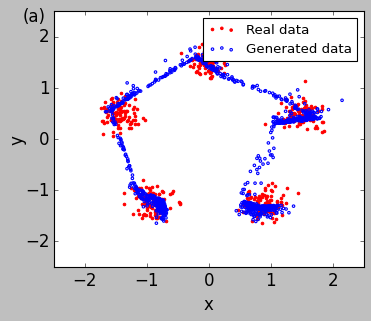

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
from sklearn.mixture import GaussianMixture
import copy

# 设置随机数种子
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std=0):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()
        self.noise_std = noise_std

    def forward(self, z_input):
        # 添加噪声到输入
        z_input = z_input + torch.randn_like(z_input) * self.noise_std
        g_y1 = self.relu(self.fc1(z_input))
        g_y1 = g_y1 + torch.randn_like(g_y1) * self.noise_std  # 添加噪声到隐藏层
        g_y2 = self.relu(self.fc2(g_y1))
        g_y2 = g_y2 + torch.randn_like(g_y2) * self.noise_std  # 添加噪声到隐藏层
        g_y3 = self.relu(self.fc3(g_y2))
        g_y3 = g_y3 + torch.randn_like(g_y3) * self.noise_std  # 添加噪声到隐藏层
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std=0):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.noise_std = noise_std

    def forward(self, x_input):
        # 添加噪声到输入
        x_input = x_input + torch.randn_like(x_input) * self.noise_std
        d_y1 = self.relu(self.fc1(x_input))
        d_y1 = d_y1 + torch.randn_like(d_y1) * self.noise_std  # 添加噪声到隐藏层
        d_y2 = self.relu(self.fc2(d_y1))
        d_y2 = d_y2 + torch.randn_like(d_y2) * self.noise_std  # 添加噪声到隐藏层
        d_y3 = self.relu(self.fc3(d_y2))
        d_y3 = d_y3 + torch.randn_like(d_y3) * self.noise_std  # 添加噪声到隐藏层
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

def generator_loss(d_fake):
    # 生成器希望 d_fake 接近 1
    return -torch.mean(torch.log(d_fake + 1e-8))

# 梯度噪声注入函数
def add_gradient_noise(parameters, grad_noise_std):
    for param in parameters:
        if param.grad is not None:
            noise = torch.randn_like(param.grad) * grad_noise_std
            param.grad += noise

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32
noise_std = 0  # 隐藏层噪声标准差
grad_noise_std = 0.02  # 梯度噪声标准差

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 5000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

# Training loop
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        add_gradient_noise(discriminator.parameters(), grad_noise_std)  # 梯度噪声注入
        d_optimizer.step()

        # Train generator
        d_fake, _ = discriminator(fake_img)

        # 使用自定义的生成器损失函数
        g_loss = generator_loss(d_fake)

        g_optimizer.zero_grad()
        g_loss.backward()
        add_gradient_noise(generator.parameters(), grad_noise_std)  # 梯度噪声注入
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))

    # Print losses every 20 epochs
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, G Loss: {np.mean(batch_generator_loss):.4f}")

plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['classic'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
# fig.savefig('D:/GAN2024/Fig1a.eps', dpi=800)
# 显示图 (a)
plt.show()

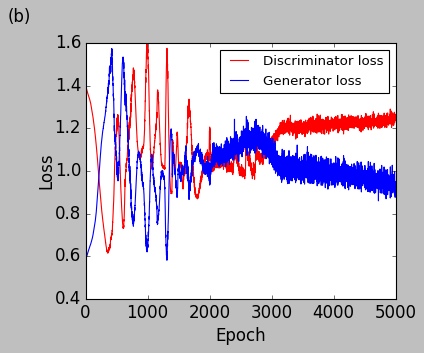

In [21]:
# 图 (b): 损失曲线
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('Epoch', fontsize=15)
ax.set_ylabel('Loss', fontsize=15, labelpad=-1)

# 绘制判别器损失曲线
ax.plot(epoch_discriminator_loss, color='red', label='Discriminator loss')
# 绘制生成器损失曲线
ax.plot(epoch_generator_loss, color='blue', label='Generator loss')
ax.legend(loc='upper right', fontsize=12)
ax.text(-1250, max(epoch_discriminator_loss) + 0.1, '(b)', fontsize=15)  # 标记 (b)
# fig.savefig('D:/GAN2024/Fig1b.eps', dpi=800)
# 显示图 (b)
plt.show()

In [22]:
# 自适应调整噪声强度
n_iterations = 10  # 自适应调整噪声强度的迭代次数
step_size=0.005 # 自适应调整噪声强度的步长

def adapt_noise_stds(generator, X_train, n_iterations, noise_std, grad_noise_std, step_size):
    best_gmm_score = float('inf')
    best_noise_std, best_grad_noise_std = noise_std, grad_noise_std
    
    for _ in range(n_iterations):
        # 生成数据
        #samples = generator(torch.randn(1000, z_dim)).detach().numpy()
        
        # 估计GMM参数
        gmm_real = GaussianMixture(n_components=2, covariance_type='full', random_state=seed).fit(X_train)
        gmm_gen = GaussianMixture(n_components=2, covariance_type='full', random_state=seed).fit(samples)
        
        # 计算评分（可以使用AIC, BIC等）值越低越好
        score_real = gmm_real.aic(X_train)
        score_gen = gmm_gen.aic(samples)
        print(score_gen)
        gmm_score = abs(score_real - score_gen)
        
        # 更新噪声强度
        if gmm_score < best_gmm_score:
            best_gmm_score = gmm_score
            best_noise_std = max(0, noise_std - step_size)  # 避免噪声强度变为负数
            best_grad_noise_std = max(0, grad_noise_std - step_size * 0.5)  # 对梯度噪声使用不同的步长（可选）
        else:
            noise_std_increment = step_size
            grad_noise_std_increment = step_size * 0.5  # 对梯度噪声使用不同的步长（可选）
            best_noise_std = noise_std + noise_std_increment
            best_grad_noise_std = grad_noise_std + grad_noise_std_increment
        
        print(f"Noise Std: {best_noise_std}, Grad Noise Std: {best_grad_noise_std}, GMM Score: {gmm_score}")
    
    return best_noise_std, best_grad_noise_std

best_noise_std, best_grad_noise_std = adapt_noise_stds(generator, X_train, n_iterations, noise_std, grad_noise_std, step_size)
print(f"Best Noise Standard Deviation: {best_noise_std}, Best Gradient Noise Standard Deviation: {best_grad_noise_std}")

4187.2826949838945
Noise Std: 0, Grad Noise Std: 0.0175, GMM Score: 1669.6750897111106
4187.2826949838945
Noise Std: 0.005, Grad Noise Std: 0.0225, GMM Score: 1669.6750897111106
4187.2826949838945
Noise Std: 0.005, Grad Noise Std: 0.0225, GMM Score: 1669.6750897111106
4187.2826949838945
Noise Std: 0.005, Grad Noise Std: 0.0225, GMM Score: 1669.6750897111106
4187.2826949838945
Noise Std: 0.005, Grad Noise Std: 0.0225, GMM Score: 1669.6750897111106
4187.2826949838945
Noise Std: 0.005, Grad Noise Std: 0.0225, GMM Score: 1669.6750897111106
4187.2826949838945
Noise Std: 0.005, Grad Noise Std: 0.0225, GMM Score: 1669.6750897111106
4187.2826949838945
Noise Std: 0.005, Grad Noise Std: 0.0225, GMM Score: 1669.6750897111106
4187.2826949838945
Noise Std: 0.005, Grad Noise Std: 0.0225, GMM Score: 1669.6750897111106
4187.2826949838945
Noise Std: 0.005, Grad Noise Std: 0.0225, GMM Score: 1669.6750897111106
Best Noise Standard Deviation: 0.005, Best Gradient Noise Standard Deviation: 0.0225


Epoch 0: D Loss: 1.4048, G Loss: 0.8433
Epoch 20: D Loss: 1.3907, G Loss: 0.8157
Epoch 40: D Loss: 1.3782, G Loss: 0.7904
Epoch 60: D Loss: 1.3667, G Loss: 0.7713
Epoch 80: D Loss: 1.3545, G Loss: 0.7540
Epoch 100: D Loss: 1.3345, G Loss: 0.7389
Epoch 120: D Loss: 1.3095, G Loss: 0.7343
Epoch 140: D Loss: 1.2662, G Loss: 0.7353
Epoch 160: D Loss: 1.2118, G Loss: 0.7533
Epoch 180: D Loss: 1.1329, G Loss: 0.7759
Epoch 200: D Loss: 1.0369, G Loss: 0.8266
Epoch 220: D Loss: 0.9406, G Loss: 0.8773
Epoch 240: D Loss: 0.8627, G Loss: 0.9574
Epoch 260: D Loss: 0.8481, G Loss: 0.9585
Epoch 280: D Loss: 0.8973, G Loss: 1.0087
Epoch 300: D Loss: 0.8758, G Loss: 1.1510
Epoch 320: D Loss: 0.7793, G Loss: 1.3677
Epoch 340: D Loss: 0.6736, G Loss: 1.5353
Epoch 360: D Loss: 0.7018, G Loss: 1.5705
Epoch 380: D Loss: 0.7087, G Loss: 1.7539
Epoch 400: D Loss: 0.6227, G Loss: 1.9005
Epoch 420: D Loss: 0.5850, G Loss: 1.8990
Epoch 440: D Loss: 0.5865, G Loss: 1.7658
Epoch 460: D Loss: 0.6468, G Loss: 1.595

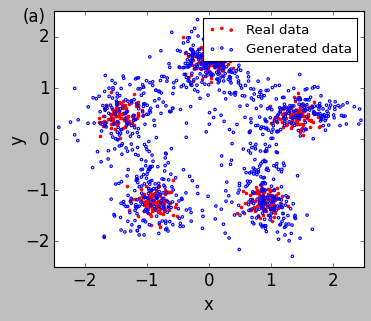

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
from sklearn.mixture import GaussianMixture
import copy


# 设置随机数种子
seed = 166
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std=0):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()
        self.noise_std = noise_std

    def forward(self, z_input):
        # 添加噪声到输入
        z_input = z_input + torch.randn_like(z_input) * self.noise_std
        g_y1 = self.relu(self.fc1(z_input))
        g_y1 = g_y1 + torch.randn_like(g_y1) * self.noise_std  # 添加噪声到隐藏层
        g_y2 = self.relu(self.fc2(g_y1))
        g_y2 = g_y2 + torch.randn_like(g_y2) * self.noise_std  # 添加噪声到隐藏层
        g_y3 = self.relu(self.fc3(g_y2))
        g_y3 = g_y3 + torch.randn_like(g_y3) * self.noise_std  # 添加噪声到隐藏层
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std=0):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.noise_std = noise_std

    def forward(self, x_input):
        # 添加噪声到输入
        x_input = x_input + torch.randn_like(x_input) * self.noise_std
        d_y1 = self.relu(self.fc1(x_input))
        d_y1 = d_y1 + torch.randn_like(d_y1) * self.noise_std  # 添加噪声到隐藏层
        d_y2 = self.relu(self.fc2(d_y1))
        d_y2 = d_y2 + torch.randn_like(d_y2) * self.noise_std  # 添加噪声到隐藏层
        d_y3 = self.relu(self.fc3(d_y2))
        d_y3 = d_y3 + torch.randn_like(d_y3) * self.noise_std  # 添加噪声到隐藏层
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

def generator_loss(d_fake):
    # 生成器希望 d_fake 接近 1
    return -torch.mean(torch.log(d_fake + 1e-8))

# 梯度噪声注入函数
def add_gradient_noise(parameters, grad_noise_std):
    for param in parameters:
        if param.grad is not None:
            noise = torch.randn_like(param.grad) * grad_noise_std
            param.grad += noise

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32
noise_std = 0.1  # 隐藏层噪声标准差
grad_noise_std = 0.015  # 梯度噪声标准差

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 5000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

# Training loop
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        add_gradient_noise(discriminator.parameters(), grad_noise_std)  # 梯度噪声注入
        d_optimizer.step()

        # Train generator
        d_fake, _ = discriminator(fake_img)

        # 使用自定义的生成器损失函数
        g_loss = generator_loss(d_fake)

        g_optimizer.zero_grad()
        g_loss.backward()
        add_gradient_noise(generator.parameters(), grad_noise_std)  # 梯度噪声注入
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))

    # Print losses every 20 epochs
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, G Loss: {np.mean(batch_generator_loss):.4f}")

plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['classic'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
# fig.savefig('D:/GAN2024/Fig1a.eps', dpi=800)
# 显示图 (a)
plt.show()

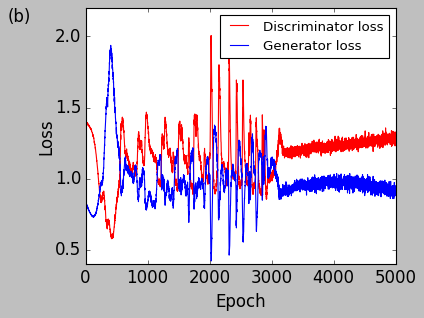

In [24]:
# 图 (b): 损失曲线
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('Epoch', fontsize=15)
ax.set_ylabel('Loss', fontsize=15, labelpad=-1)

# 绘制判别器损失曲线
ax.plot(epoch_discriminator_loss, color='red', label='Discriminator loss')
# 绘制生成器损失曲线
ax.plot(epoch_generator_loss, color='blue', label='Generator loss')
ax.legend(loc='upper right', fontsize=12)
ax.text(-1250, max(epoch_discriminator_loss) + 0.1, '(b)', fontsize=15)  # 标记 (b)
# fig.savefig('D:/GAN2024/Fig1b.eps', dpi=800)
# 显示图 (b)
plt.show()

In [25]:
# 自适应调整噪声强度
n_iterations = 10  # 自适应调整噪声强度的迭代次数
step_size=0.005 # 自适应调整噪声强度的步长

def adapt_noise_stds(generator, X_train, n_iterations, noise_std, grad_noise_std, step_size):
    best_gmm_score = float('inf')
    best_noise_std, best_grad_noise_std = noise_std, grad_noise_std
    
    for _ in range(n_iterations):
        # 生成数据
        #samples = generator(torch.randn(1000, z_dim)).detach().numpy()
        
        # 估计GMM参数
        gmm_real = GaussianMixture(n_components=2, covariance_type='full', random_state=seed).fit(X_train)
        gmm_gen = GaussianMixture(n_components=2, covariance_type='full', random_state=seed).fit(samples)
        
        # 计算评分（可以使用AIC, BIC等）值越低越好
        score_real = gmm_real.aic(X_train)
        score_gen = gmm_gen.aic(samples)
        print(score_gen)
        gmm_score = abs(score_real - score_gen)
        
        # 更新噪声强度
        if gmm_score < best_gmm_score:
            best_gmm_score = gmm_score
            best_noise_std = max(0, noise_std - step_size)  # 避免噪声强度变为负数
            best_grad_noise_std = max(0, grad_noise_std - step_size * 0.5)  # 对梯度噪声使用不同的步长（可选）
        else:
            noise_std_increment = step_size
            grad_noise_std_increment = step_size * 0.5  # 对梯度噪声使用不同的步长（可选）
            best_noise_std = noise_std + noise_std_increment
            best_grad_noise_std = grad_noise_std + grad_noise_std_increment
        
        print(f"Noise Std: {best_noise_std}, Grad Noise Std: {best_grad_noise_std}, GMM Score: {gmm_score}")
    
    return best_noise_std, best_grad_noise_std

best_noise_std, best_grad_noise_std = adapt_noise_stds(generator, X_train, n_iterations, noise_std, grad_noise_std, step_size)
print(f"Best Noise Standard Deviation: {best_noise_std}, Best Gradient Noise Standard Deviation: {best_grad_noise_std}")

5672.998348317185
Noise Std: 0.095, Grad Noise Std: 0.012499999999999999, GMM Score: 3192.6269639172456
5672.998348317185
Noise Std: 0.10500000000000001, Grad Noise Std: 0.017499999999999998, GMM Score: 3192.6269639172456
5672.998348317185
Noise Std: 0.10500000000000001, Grad Noise Std: 0.017499999999999998, GMM Score: 3192.6269639172456
5672.998348317185
Noise Std: 0.10500000000000001, Grad Noise Std: 0.017499999999999998, GMM Score: 3192.6269639172456
5672.998348317185
Noise Std: 0.10500000000000001, Grad Noise Std: 0.017499999999999998, GMM Score: 3192.6269639172456
5672.998348317185
Noise Std: 0.10500000000000001, Grad Noise Std: 0.017499999999999998, GMM Score: 3192.6269639172456
5672.998348317185
Noise Std: 0.10500000000000001, Grad Noise Std: 0.017499999999999998, GMM Score: 3192.6269639172456
5672.998348317185
Noise Std: 0.10500000000000001, Grad Noise Std: 0.017499999999999998, GMM Score: 3192.6269639172456
5672.998348317185
Noise Std: 0.10500000000000001, Grad Noise Std: 0.01

Epoch 0: D Loss: 1.4180, G Loss: 0.8866
Epoch 20: D Loss: 1.4038, G Loss: 0.8633
Epoch 40: D Loss: 1.3926, G Loss: 0.8373
Epoch 60: D Loss: 1.3899, G Loss: 0.8201
Epoch 80: D Loss: 1.3705, G Loss: 0.8047
Epoch 100: D Loss: 1.3614, G Loss: 0.7900
Epoch 120: D Loss: 1.3479, G Loss: 0.7816
Epoch 140: D Loss: 1.3358, G Loss: 0.7772
Epoch 160: D Loss: 1.3215, G Loss: 0.7773
Epoch 180: D Loss: 1.2996, G Loss: 0.7807
Epoch 200: D Loss: 1.2798, G Loss: 0.7932
Epoch 220: D Loss: 1.2593, G Loss: 0.8045
Epoch 240: D Loss: 1.2392, G Loss: 0.8231
Epoch 260: D Loss: 1.2011, G Loss: 0.8709
Epoch 280: D Loss: 1.1424, G Loss: 0.9629
Epoch 300: D Loss: 1.0573, G Loss: 1.0720
Epoch 320: D Loss: 0.9812, G Loss: 1.1359
Epoch 340: D Loss: 0.9349, G Loss: 1.1476
Epoch 360: D Loss: 0.9110, G Loss: 1.1260
Epoch 380: D Loss: 0.8861, G Loss: 1.1066
Epoch 400: D Loss: 0.8573, G Loss: 1.0917
Epoch 420: D Loss: 0.8205, G Loss: 1.1054
Epoch 440: D Loss: 0.8119, G Loss: 1.1088
Epoch 460: D Loss: 0.8152, G Loss: 1.094

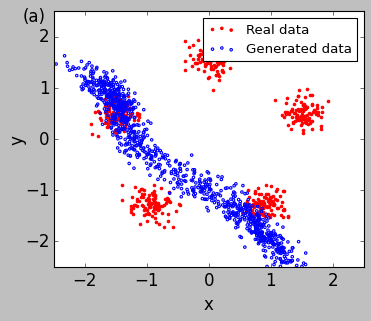

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
from sklearn.mixture import GaussianMixture
import copy


# 设置随机数种子
seed = 1234
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std=0):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()
        self.noise_std = noise_std

    def forward(self, z_input):
        # 添加噪声到输入
        z_input = z_input + torch.randn_like(z_input) * self.noise_std
        g_y1 = self.relu(self.fc1(z_input))
        g_y1 = g_y1 + torch.randn_like(g_y1) * self.noise_std  # 添加噪声到隐藏层
        g_y2 = self.relu(self.fc2(g_y1))
        g_y2 = g_y2 + torch.randn_like(g_y2) * self.noise_std  # 添加噪声到隐藏层
        g_y3 = self.relu(self.fc3(g_y2))
        g_y3 = g_y3 + torch.randn_like(g_y3) * self.noise_std  # 添加噪声到隐藏层
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std=0):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.noise_std = noise_std

    def forward(self, x_input):
        # 添加噪声到输入
        x_input = x_input + torch.randn_like(x_input) * self.noise_std
        d_y1 = self.relu(self.fc1(x_input))
        d_y1 = d_y1 + torch.randn_like(d_y1) * self.noise_std  # 添加噪声到隐藏层
        d_y2 = self.relu(self.fc2(d_y1))
        d_y2 = d_y2 + torch.randn_like(d_y2) * self.noise_std  # 添加噪声到隐藏层
        d_y3 = self.relu(self.fc3(d_y2))
        d_y3 = d_y3 + torch.randn_like(d_y3) * self.noise_std  # 添加噪声到隐藏层
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

def generator_loss(d_fake):
    # 生成器希望 d_fake 接近 1
    return -torch.mean(torch.log(d_fake + 1e-8))

# 梯度噪声注入函数
def add_gradient_noise(parameters, grad_noise_std):
    for param in parameters:
        if param.grad is not None:
            noise = torch.randn_like(param.grad) * grad_noise_std
            param.grad += noise

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32
noise_std = 0.1  # 隐藏层噪声标准差
grad_noise_std = 0.015  # 梯度噪声标准差

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 5000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

# Training loop
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        add_gradient_noise(discriminator.parameters(), grad_noise_std)  # 梯度噪声注入
        d_optimizer.step()

        # Train generator
        d_fake, _ = discriminator(fake_img)

        # 使用自定义的生成器损失函数
        g_loss = generator_loss(d_fake)

        g_optimizer.zero_grad()
        g_loss.backward()
        add_gradient_noise(generator.parameters(), grad_noise_std)  # 梯度噪声注入
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))

    # Print losses every 20 epochs
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, G Loss: {np.mean(batch_generator_loss):.4f}")

plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['classic'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
# fig.savefig('D:/GAN2024/Fig1a.eps', dpi=800)
# 显示图 (a)
plt.show()

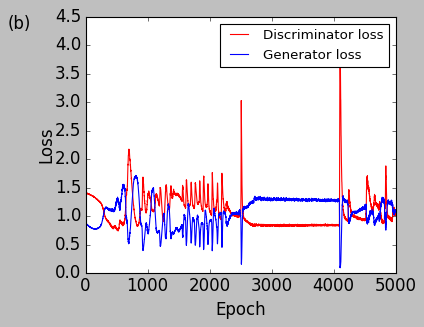

In [27]:
# 图 (b): 损失曲线
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('Epoch', fontsize=15)
ax.set_ylabel('Loss', fontsize=15, labelpad=-1)

# 绘制判别器损失曲线
ax.plot(epoch_discriminator_loss, color='red', label='Discriminator loss')
# 绘制生成器损失曲线
ax.plot(epoch_generator_loss, color='blue', label='Generator loss')
ax.legend(loc='upper right', fontsize=12)
ax.text(-1250, max(epoch_discriminator_loss) + 0.1, '(b)', fontsize=15)  # 标记 (b)
# fig.savefig('D:/GAN2024/Fig1b.eps', dpi=800)
# 显示图 (b)
plt.show()

In [28]:
# 自适应调整噪声强度
n_iterations = 10  # 自适应调整噪声强度的迭代次数
step_size=0.005 # 自适应调整噪声强度的步长

def adapt_noise_stds(generator, X_train, n_iterations, noise_std, grad_noise_std, step_size):
    best_gmm_score = float('inf')
    best_noise_std, best_grad_noise_std = noise_std, grad_noise_std
    
    for _ in range(n_iterations):
        # 生成数据
        #samples = generator(torch.randn(1000, z_dim)).detach().numpy()
        
        # 估计GMM参数
        gmm_real = GaussianMixture(n_components=2, covariance_type='full', random_state=seed).fit(X_train)
        gmm_gen = GaussianMixture(n_components=2, covariance_type='full', random_state=seed).fit(samples)
        
        # 计算评分（可以使用AIC, BIC等）值越低越好
        score_real = gmm_real.aic(X_train)
        score_gen = gmm_gen.aic(samples)
        print(score_gen)
        gmm_score = abs(score_real - score_gen)
        
        # 更新噪声强度
        if gmm_score < best_gmm_score:
            best_gmm_score = gmm_score
            best_noise_std = max(0, noise_std - step_size)  # 避免噪声强度变为负数
            best_grad_noise_std = max(0, grad_noise_std - step_size * 0.5)  # 对梯度噪声使用不同的步长（可选）
        else:
            noise_std_increment = step_size
            grad_noise_std_increment = step_size * 0.5  # 对梯度噪声使用不同的步长（可选）
            best_noise_std = noise_std + noise_std_increment
            best_grad_noise_std = grad_noise_std + grad_noise_std_increment
        
        print(f"Noise Std: {best_noise_std}, Grad Noise Std: {best_grad_noise_std}, GMM Score: {gmm_score}")
    
    return best_noise_std, best_grad_noise_std

best_noise_std, best_grad_noise_std = adapt_noise_stds(generator, X_train, n_iterations, noise_std, grad_noise_std, step_size)
print(f"Best Noise Standard Deviation: {best_noise_std}, Best Gradient Noise Standard Deviation: {best_grad_noise_std}")

2622.582333337129
Noise Std: 0.095, Grad Noise Std: 0.012499999999999999, GMM Score: 87.73992966597325
2622.582333337129
Noise Std: 0.10500000000000001, Grad Noise Std: 0.017499999999999998, GMM Score: 87.73992966597325
2622.582333337129
Noise Std: 0.10500000000000001, Grad Noise Std: 0.017499999999999998, GMM Score: 87.73992966597325
2622.582333337129
Noise Std: 0.10500000000000001, Grad Noise Std: 0.017499999999999998, GMM Score: 87.73992966597325
2622.582333337129
Noise Std: 0.10500000000000001, Grad Noise Std: 0.017499999999999998, GMM Score: 87.73992966597325
2622.582333337129
Noise Std: 0.10500000000000001, Grad Noise Std: 0.017499999999999998, GMM Score: 87.73992966597325
2622.582333337129
Noise Std: 0.10500000000000001, Grad Noise Std: 0.017499999999999998, GMM Score: 87.73992966597325
2622.582333337129
Noise Std: 0.10500000000000001, Grad Noise Std: 0.017499999999999998, GMM Score: 87.73992966597325
2622.582333337129
Noise Std: 0.10500000000000001, Grad Noise Std: 0.0174999999

Epoch 0: D Loss: 1.3675, G Loss: 0.6588
Epoch 20: D Loss: 1.3448, G Loss: 0.6777
Epoch 40: D Loss: 1.3185, G Loss: 0.6928
Epoch 60: D Loss: 1.2942, G Loss: 0.7067
Epoch 80: D Loss: 1.2699, G Loss: 0.7173
Epoch 100: D Loss: 1.2412, G Loss: 0.7298
Epoch 120: D Loss: 1.2054, G Loss: 0.7447
Epoch 140: D Loss: 1.1594, G Loss: 0.7641
Epoch 160: D Loss: 1.1037, G Loss: 0.7872
Epoch 180: D Loss: 1.0466, G Loss: 0.8124
Epoch 200: D Loss: 0.9839, G Loss: 0.8450
Epoch 220: D Loss: 0.9198, G Loss: 0.8908
Epoch 240: D Loss: 0.8644, G Loss: 0.9384
Epoch 260: D Loss: 0.8050, G Loss: 1.0029
Epoch 280: D Loss: 0.7484, G Loss: 1.0615
Epoch 300: D Loss: 0.6749, G Loss: 1.1550
Epoch 320: D Loss: 0.6142, G Loss: 1.2419
Epoch 340: D Loss: 0.6470, G Loss: 1.2615
Epoch 360: D Loss: 0.7071, G Loss: 1.3147
Epoch 380: D Loss: 0.6922, G Loss: 1.4502
Epoch 400: D Loss: 0.6466, G Loss: 1.4875
Epoch 420: D Loss: 0.6039, G Loss: 1.4779
Epoch 440: D Loss: 0.5682, G Loss: 1.4923
Epoch 460: D Loss: 0.6023, G Loss: 1.378

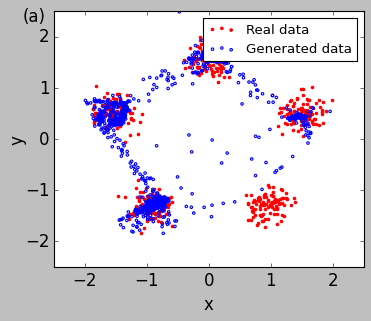

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
from sklearn.mixture import GaussianMixture
import copy


# 设置随机数种子
seed = 4321
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std=0):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()
        self.noise_std = noise_std

    def forward(self, z_input):
        # 添加噪声到输入
        z_input = z_input + torch.randn_like(z_input) * self.noise_std
        g_y1 = self.relu(self.fc1(z_input))
        g_y1 = g_y1 + torch.randn_like(g_y1) * self.noise_std  # 添加噪声到隐藏层
        g_y2 = self.relu(self.fc2(g_y1))
        g_y2 = g_y2 + torch.randn_like(g_y2) * self.noise_std  # 添加噪声到隐藏层
        g_y3 = self.relu(self.fc3(g_y2))
        g_y3 = g_y3 + torch.randn_like(g_y3) * self.noise_std  # 添加噪声到隐藏层
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std=0):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.noise_std = noise_std

    def forward(self, x_input):
        # 添加噪声到输入
        x_input = x_input + torch.randn_like(x_input) * self.noise_std
        d_y1 = self.relu(self.fc1(x_input))
        d_y1 = d_y1 + torch.randn_like(d_y1) * self.noise_std  # 添加噪声到隐藏层
        d_y2 = self.relu(self.fc2(d_y1))
        d_y2 = d_y2 + torch.randn_like(d_y2) * self.noise_std  # 添加噪声到隐藏层
        d_y3 = self.relu(self.fc3(d_y2))
        d_y3 = d_y3 + torch.randn_like(d_y3) * self.noise_std  # 添加噪声到隐藏层
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

def generator_loss(d_fake):
    # 生成器希望 d_fake 接近 1
    return -torch.mean(torch.log(d_fake + 1e-8))

# 梯度噪声注入函数
def add_gradient_noise(parameters, grad_noise_std):
    for param in parameters:
        if param.grad is not None:
            noise = torch.randn_like(param.grad) * grad_noise_std
            param.grad += noise

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32
noise_std = 0.005  # 隐藏层噪声标准差
grad_noise_std = 0.02  # 梯度噪声标准差

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 5000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

# Training loop
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        add_gradient_noise(discriminator.parameters(), grad_noise_std)  # 梯度噪声注入
        d_optimizer.step()

        # Train generator
        d_fake, _ = discriminator(fake_img)

        # 使用自定义的生成器损失函数
        g_loss = generator_loss(d_fake)

        g_optimizer.zero_grad()
        g_loss.backward()
        add_gradient_noise(generator.parameters(), grad_noise_std)  # 梯度噪声注入
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))

    # Print losses every 20 epochs
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, G Loss: {np.mean(batch_generator_loss):.4f}")

plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['classic'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
# fig.savefig('D:/GAN2024/Fig1a.eps', dpi=800)
# 显示图 (a)
plt.show()

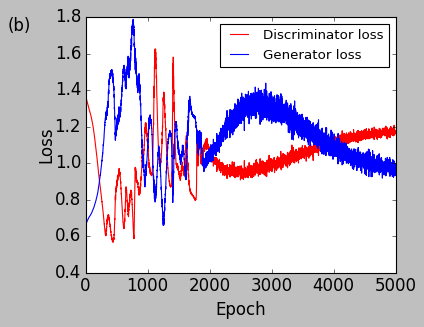

In [30]:
# 图 (b): 损失曲线
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('Epoch', fontsize=15)
ax.set_ylabel('Loss', fontsize=15, labelpad=-1)

# 绘制判别器损失曲线
ax.plot(epoch_discriminator_loss, color='red', label='Discriminator loss')
# 绘制生成器损失曲线
ax.plot(epoch_generator_loss, color='blue', label='Generator loss')
ax.legend(loc='upper right', fontsize=12)
ax.text(-1250, max(epoch_discriminator_loss) + 0.1, '(b)', fontsize=15)  # 标记 (b)
# fig.savefig('D:/GAN2024/Fig1b.eps', dpi=800)
# 显示图 (b)
plt.show()

In [31]:
# 自适应调整噪声强度
n_iterations = 10  # 自适应调整噪声强度的迭代次数
step_size=0.01 # 自适应调整噪声强度的步长

def adapt_noise_stds(generator, X_train, n_iterations, noise_std, grad_noise_std, step_size):
    best_gmm_score = float('inf')
    best_noise_std, best_grad_noise_std = noise_std, grad_noise_std
    
    for _ in range(n_iterations):
        # 生成数据
        #samples = generator(torch.randn(1000, z_dim)).detach().numpy()
        
        # 估计GMM参数
        gmm_real = GaussianMixture(n_components=2, covariance_type='full', random_state=seed).fit(X_train)
        gmm_gen = GaussianMixture(n_components=2, covariance_type='full', random_state=seed).fit(samples)
        
        # 计算评分（可以使用AIC, BIC等）值越低越好
        score_real = gmm_real.aic(X_train)
        score_gen = gmm_gen.aic(samples)
        print(score_gen)
        gmm_score = abs(score_real - score_gen)
        
        # 更新噪声强度
        if gmm_score < best_gmm_score:
            best_gmm_score = gmm_score
            best_noise_std = max(0, noise_std - step_size)  # 避免噪声强度变为负数
            best_grad_noise_std = max(0, grad_noise_std - step_size * 0.5)  # 对梯度噪声使用不同的步长（可选）
        else:
            noise_std_increment = step_size
            grad_noise_std_increment = step_size * 0.5  # 对梯度噪声使用不同的步长（可选）
            best_noise_std = noise_std + noise_std_increment
            best_grad_noise_std = grad_noise_std + grad_noise_std_increment
        
        print(f"Noise Std: {best_noise_std}, Grad Noise Std: {best_grad_noise_std}, GMM Score: {gmm_score}")
    
    return best_noise_std, best_grad_noise_std

best_noise_std, best_grad_noise_std = adapt_noise_stds(generator, X_train, n_iterations, noise_std, grad_noise_std, step_size)
print(f"Best Noise Standard Deviation: {best_noise_std}, Best Gradient Noise Standard Deviation: {best_grad_noise_std}")

3942.4687145126863
Noise Std: 0, Grad Noise Std: 0.015, GMM Score: 1362.6097961466248
3942.4687145126863
Noise Std: 0.015, Grad Noise Std: 0.025, GMM Score: 1362.6097961466248
3942.4687145126863
Noise Std: 0.015, Grad Noise Std: 0.025, GMM Score: 1362.6097961466248
3942.4687145126863
Noise Std: 0.015, Grad Noise Std: 0.025, GMM Score: 1362.6097961466248
3942.4687145126863
Noise Std: 0.015, Grad Noise Std: 0.025, GMM Score: 1362.6097961466248
3942.4687145126863
Noise Std: 0.015, Grad Noise Std: 0.025, GMM Score: 1362.6097961466248
3942.4687145126863
Noise Std: 0.015, Grad Noise Std: 0.025, GMM Score: 1362.6097961466248
3942.4687145126863
Noise Std: 0.015, Grad Noise Std: 0.025, GMM Score: 1362.6097961466248
3942.4687145126863
Noise Std: 0.015, Grad Noise Std: 0.025, GMM Score: 1362.6097961466248
3942.4687145126863
Noise Std: 0.015, Grad Noise Std: 0.025, GMM Score: 1362.6097961466248
Best Noise Standard Deviation: 0.015, Best Gradient Noise Standard Deviation: 0.025


In [ ]:
#########end，下面进行激活函数更换实验